# Olist Pricing Strategy & Voucher Effectiveness
**Data Sprint - Group 2** (Ayman, Isa, Alfadhul)

# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar
import pathlib
from matplotlib.ticker import PercentFormatter

The data files are expected in a `Data/` folder next to the `Code/` folder that holds this notebook.

In [2]:
olist_sellers_df = pd.read_csv('../Data/olist_sellers_dataset.csv')
product_category_name_translation_df = pd.read_csv('../Data/product_category_name_translation.csv')
olist_customers_df = pd.read_csv('../Data/olist_customers_dataset.csv')
olist_geolocation_df = pd.read_csv('../Data/olist_geolocation_dataset.csv')
olist_order_items_df = pd.read_csv('../Data/olist_order_items_dataset.csv')
olist_order_payments_df = pd.read_csv('../Data/olist_order_payments_dataset.csv')
olist_orders_df = pd.read_csv('../Data/olist_orders_dataset.csv')
olist_products_df = pd.read_csv('../Data/olist_products_dataset.csv')

# Part 1 - Installments and vouchers (Alfadhul)

## Q1 - Are installments and vouchers effective?

In [3]:
payments_orders_df= pd.merge(olist_order_payments_df, olist_orders_df, on='order_id', how='left')

In [4]:
payments_orders_df["used_voucher"] = payments_orders_df["payment_type"] == "voucher"

In [5]:
payments_orders_df= pd.merge(payments_orders_df, olist_customers_df, on='customer_id', how='left')

In [6]:
payments_orders_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,used_voucher,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,0a8556ac6be836b46b3e89920d59291c,delivered,2018-04-25 22:01:49,2018-04-25 22:15:09,2018-05-02 15:20:00,2018-05-09 17:36:51,2018-05-22 00:00:00,False,708ab75d2a007f0564aedd11139c7708,39801,teofilo otoni,MG
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,f2c7fc58a9de810828715166c672f10a,delivered,2018-06-26 11:01:38,2018-06-26 11:18:58,2018-06-28 14:18:00,2018-06-29 20:32:09,2018-07-16 00:00:00,False,a8b9d3a27068454b1c98cc67d4e31e6f,2422,sao paulo,SP
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,25b14b69de0b6e184ae6fe2755e478f9,delivered,2017-12-12 11:19:55,2017-12-14 09:52:34,2017-12-15 20:13:22,2017-12-18 17:24:41,2018-01-04 00:00:00,False,6f70c0b2f7552832ba46eb57b1c5651e,2652,sao paulo,SP
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,7a5d8efaaa1081f800628c30d2b0728f,delivered,2017-12-06 12:04:06,2017-12-06 12:13:20,2017-12-07 20:28:28,2017-12-21 01:35:51,2018-01-04 00:00:00,False,87695ed086ebd36f20404c82d20fca87,36060,juiz de fora,MG
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,15fd6fb8f8312dbb4674e4518d6fa3b3,delivered,2018-05-21 13:59:17,2018-05-21 16:14:41,2018-05-22 11:46:00,2018-06-01 21:44:53,2018-06-13 00:00:00,False,4291db0da71914754618cd789aebcd56,18570,conchas,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,5d576cb2dfa3bc05612c392a1ee9c654,delivered,2018-03-08 16:57:23,2018-03-10 03:55:25,2018-03-12 18:19:36,2018-03-16 13:09:51,2018-04-04 00:00:00,False,b6027ac07fb76ebca8c97b1887865aee,12954,atibaia,SP
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,2079230c765a88530822a34a4cec2aa0,delivered,2017-08-18 09:45:35,2017-08-18 10:04:56,2017-08-18 18:04:24,2017-08-23 22:25:56,2017-09-12 00:00:00,False,53b30ca78efb2b7efcd3f9e461587eb2,30210,belo horizonte,MG
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,e4abb5057ec8cfda9759c0dc415a8188,invoiced,2017-11-18 17:27:14,2017-11-18 17:46:05,NaN,NaN,2017-12-05 00:00:00,False,d3c7da954a324253814096bcaf240e4e,1519,sao paulo,SP
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,5d719b0d300663188169c6560e243f27,delivered,2018-08-07 23:26:13,2018-08-07 23:45:00,2018-08-09 11:46:00,2018-08-21 22:41:46,2018-08-24 00:00:00,False,b84dc68f02f122a88d7e7bbd37b06204,22733,rio de janeiro,RJ


In [7]:
payments_orders_df["order_id"].nunique(), len(payments_orders_df)

(99440, 103886)

In [8]:
payments_orders_df["order_id"].value_counts().head(10)

order_id
fa65dad1b0e818e3ccc5cb0e39231352    29
ccf804e764ed5650cd8759557269dc13    26
285c2e15bebd4ac83635ccc563dc71f4    22
895ab968e7bb0d5659d16cd74cd1650c    21
ee9ca989fc93ba09a6eddc250ce01742    19
fedcd9f7ccdc8cba3a18defedd1a5547    19
21577126c19bf11a0b91592e5844ba78    15
4bfcba9e084f46c8e3cb49b0fa6e6159    15
3c58bffb70dcf45f12bdf66a3c215905    14
4689b1816de42507a7d63a4617383c59    14
Name: count, dtype: int64

In [9]:
payments_orders_df[payments_orders_df["order_id"] == "fa65dad1b0e818e3ccc5cb0e39231352"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,used_voucher,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
4885,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
24879,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT
32519,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,NaN,2017-05-18 00:00:00,True,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT


In [10]:
order_df = payments_orders_df.groupby("order_id").agg(
    customer_unique_id=("customer_unique_id", "first"),
    payment_value=("payment_value", "sum"),
    used_voucher=("used_voucher", "max"),
    payment_installments=("payment_installments", "max")
).reset_index()

In [11]:
order_df["used_installments"] = order_df["payment_installments"] > 1

In [12]:
order_df.shape

(99440, 6)

In [13]:
order_df.head()

,order_id,customer_unique_id,payment_value,used_voucher,payment_installments,used_installments
0,00010242fe8c5a6d1ba2dd792cb16214,871766c5855e863f6eccc05f988b23cb,72.19,False,2,True
1,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,259.83,False,3,True
2,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,216.87,False,5,True
3,00024acbcdf0a6daa1e931b038114c75,af861d436cfc08b2c2ddefd0ba074622,25.78,False,2,True
4,00042b26cf59d7ce69dfabb4e55b4fd9,64b576fb70d441e8f1b2d7d446e483c5,218.04,False,3,True


In [14]:
installment_summary = order_df.groupby("used_installments")["payment_value"].agg(
    ["count", "mean", "median", "sum"]
)

installment_summary

,count,mean,median,sum
used_installments,,,,
False,48270,121.036364,79.51,5842425.30
True,51170,198.679828,134.90,10166446.82


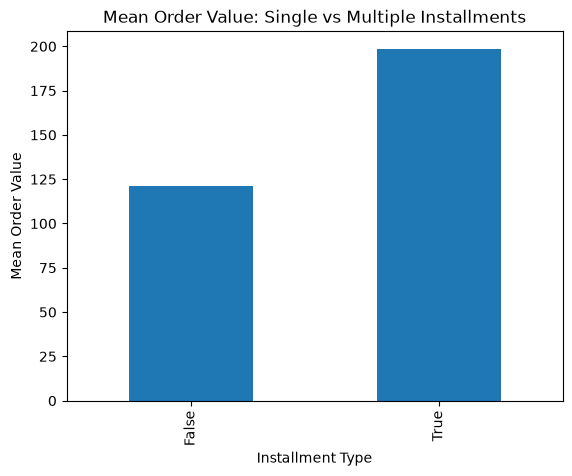

In [15]:
installment_summary["mean"].plot(kind="bar")

plt.xlabel("Installment Type")
plt.ylabel("Mean Order Value")
plt.title("Mean Order Value: Single vs Multiple Installments")
plt.savefig('1.png', dpi=300)
plt.show()

In [16]:
order_df.groupby("payment_installments")["payment_value"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
payment_installments,,,
0,2,94.315000,94.315
1,48268,121.037471,79.510
2,12363,129.124554,111.220
3,10429,144.362109,112.230
4,7070,165.060033,117.850
5,5227,184.888619,127.330
6,3908,211.594335,139.160
7,1622,189.335475,140.075
8,4251,309.774347,213.540


In [17]:
voucher_summary = order_df.groupby("used_voucher")["payment_value"].agg(
    ["count", "mean", "median", "sum"]
)

voucher_summary

,count,mean,median,sum
used_voucher,,,,
False,95574,162.018253,106.125,15484732.47
True,3866,135.576733,88.325,524139.65


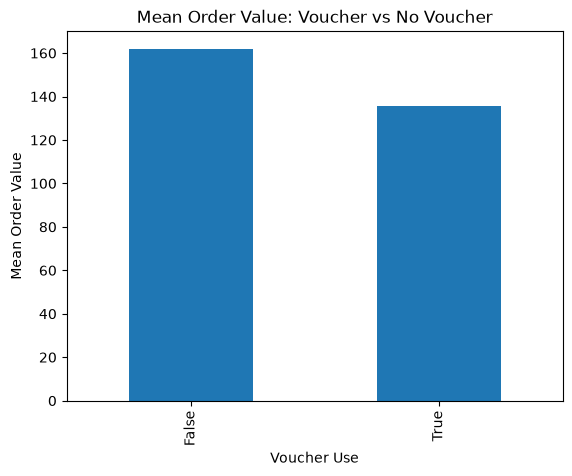

In [18]:
voucher_summary["mean"].plot(kind="bar")

plt.xlabel("Voucher Use")
plt.ylabel("Mean Order Value")
plt.title("Mean Order Value: Voucher vs No Voucher")
plt.savefig('2.png', dpi=300)

plt.show()

In [19]:
customer_df = order_df.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spend=("payment_value", "sum"),
    avg_order_value=("payment_value", "mean"),
    used_voucher=("used_voucher", "max")
).reset_index()

In [20]:
customer_df.groupby("used_voucher")[
    ["total_orders", "total_spend", "avg_order_value"]
].agg(["count", "mean", "median"])

total_orders                  total_spend                      \
                    count      mean median       count        mean  median   
used_voucher                                                                 
False               92335  1.032696    1.0       92335  167.264701  108.59   
True                 3760  1.086702    1.0        3760  150.129231   93.35   

             avg_order_value                      
                       count        mean  median  
used_voucher                                      
False                  92335  162.417689  106.51  
True                    3760  136.454326   89.39

In [21]:
customer_df = order_df.groupby("customer_unique_id").agg(
    total_orders=("order_id", "nunique"),
    total_spend=("payment_value", "sum"),
    avg_order_value=("payment_value", "mean"),
    used_installments=("used_installments", "max")
).reset_index()

In [22]:
customer_df.groupby("used_installments")[
    ["total_orders", "total_spend", "avg_order_value"]
].agg(["count", "mean", "median"])

total_orders                  total_spend              \
                         count      mean median       count        mean   
used_installments                                                         
False                    46468  1.025351    1.0       46468  124.152840   
True                     49627  1.043666    1.0       49627  206.334011   

                          avg_order_value                      
                   median           count        mean  median  
used_installments                                              
False               81.14           46468  120.934023   79.51  
True               138.87           49627  199.293598  135.49

In [23]:
order_df["installment_group"] = pd.cut(
    order_df["payment_installments"],
    bins=[0, 1, 3, 6, 10, float("inf")],
    labels=["1", "2–3", "4–6", "7–10", ">10"]
)

installment_plot = order_df.groupby("installment_group", observed=True)["payment_value"].mean()

installment_plot

installment_group
1       121.037471
2–3     136.096845
4–6     182.678056
7–10    336.489503
>10     360.369003
Name: payment_value, dtype: float64

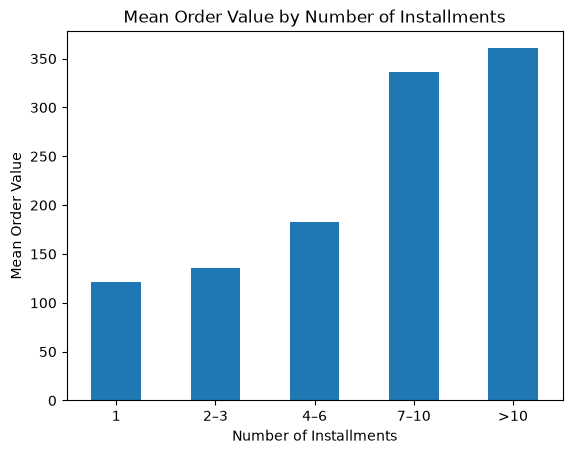

In [24]:
installment_plot.plot(kind="bar")

plt.xlabel("Number of Installments")
plt.ylabel("Mean Order Value")
plt.title("Mean Order Value by Number of Installments")
plt.xticks(rotation=0)
plt.savefig('3.png', dpi=300)

plt.show()

In [25]:
voucher_plot = order_df.groupby("used_voucher")["payment_value"].mean()

voucher_plot

used_voucher
False    162.018253
True     135.576733
Name: payment_value, dtype: float64

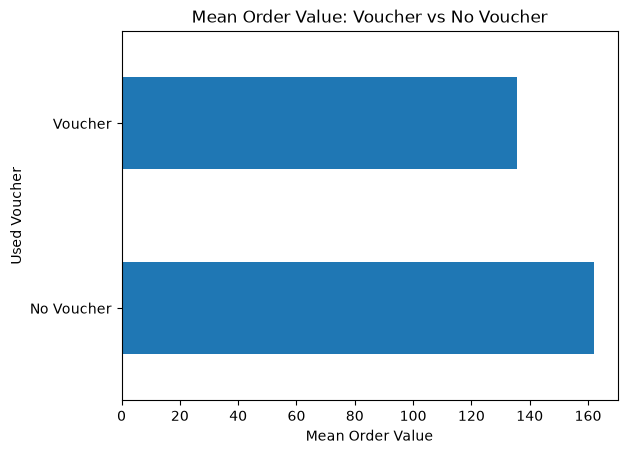

In [26]:
voucher_plot.plot(kind="barh")

plt.ylabel("Used Voucher")
plt.xlabel("Mean Order Value")
plt.title("Mean Order Value: Voucher vs No Voucher")
plt.yticks(
    ticks=[0, 1],
    labels=["No Voucher", "Voucher"])
plt.savefig('g.png', dpi=300, bbox_inches="tight")

plt.show()

## Q2 - Do vouchers increase sales or harm margins?

In [27]:
voucher_sales = order_df.groupby("used_voucher")["payment_value"].agg(
    orders="count",
    total_sales="sum"
)

voucher_sales

,orders,total_sales
used_voucher,,
False,95574,15484732.47
True,3866,524139.65


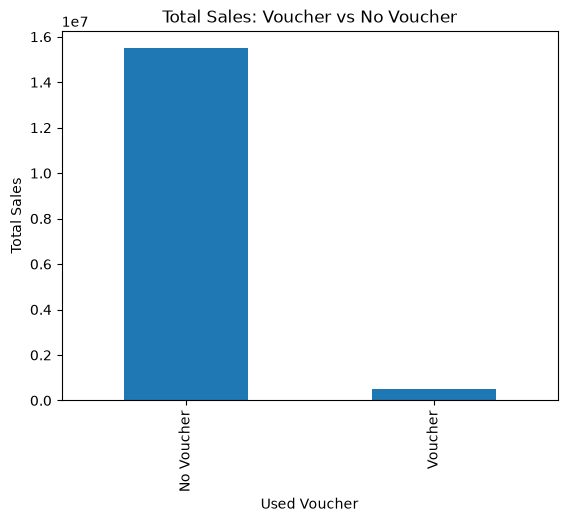

In [28]:
voucher_sales["total_sales"].plot(kind="bar")

plt.xlabel("Used Voucher")
plt.ylabel("Total Sales")
plt.title("Total Sales: Voucher vs No Voucher")
plt.xticks(
    ticks=[0, 1],
    labels=["No Voucher", "Voucher"],
)
plt.savefig('ff.png', dpi=300, bbox_inches="tight")

plt.show()

## Q3 - Are installment payments helping or hurting?

In [29]:
installment_sales = order_df.groupby("used_installments")["payment_value"].agg(
    orders="count",
    total_sales="sum",
    mean_order_value="mean"
)

installment_sales

,orders,total_sales,mean_order_value
used_installments,,,
False,48270,5842425.30,121.036364
True,51170,10166446.82,198.679828


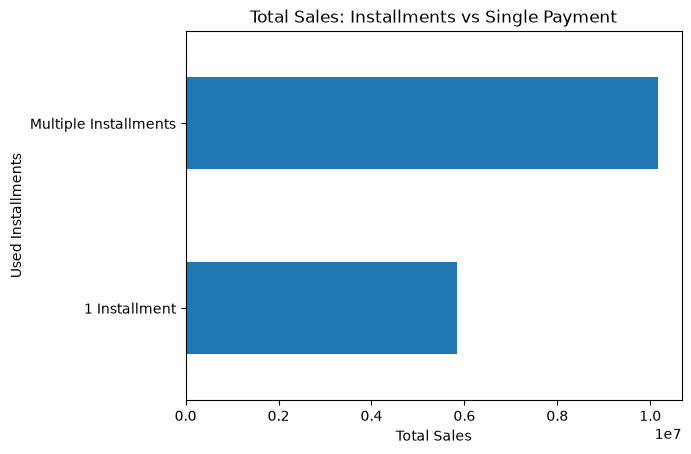

In [30]:
installment_sales["total_sales"].plot(kind="barh")

plt.ylabel("Used Installments")
plt.xlabel("Total Sales")
plt.title("Total Sales: Installments vs Single Payment")
plt.yticks(
    ticks=[0, 1],
    labels=["1 Installment", "Multiple Installments"],
)
plt.savefig('x.png', dpi=300, bbox_inches="tight")
plt.show()

# Part 2 - Voucher timing, payment types and first-time buyers (Ayman)

## -Why is there a voucher peak in August? 

In [31]:
aug = pd.merge(olist_orders_df, olist_order_payments_df, on='order_id', how='left')

In [32]:
aug.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,credit_card,3.0,179.12


In [33]:
aug.info()

<class 'pandas.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 12 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       103887 non-null  str    
 1   customer_id                    103887 non-null  str    
 2   order_status                   103887 non-null  str    
 3   order_purchase_timestamp       103887 non-null  str    
 4   order_approved_at              103712 non-null  str    
 5   order_delivered_carrier_date   101999 non-null  str    
 6   order_delivered_customer_date  100755 non-null  str    
 7   order_estimated_delivery_date  103887 non-null  str    
 8   payment_sequential             103886 non-null  float64
 9   payment_type                   103886 non-null  str    
 10  payment_installments           103886 non-null  float64
 11  payment_value                  103886 non-null  float64
dtypes: float64(3), str(9)
memory usage: 27.1 

In [34]:
aug['order_purchase_timestamp'] = pd.to_datetime(aug['order_purchase_timestamp'])
aug['month'] = aug['order_purchase_timestamp'].dt.month
aug['month_name'] = aug['order_purchase_timestamp'].dt.month_name()
aug['year'] = aug['order_purchase_timestamp'].dt.year

In [35]:
aug.month


0         10
1         10
2         10
3          7
4          8
          ..
103882     3
103883     2
103884     8
103885     1
103886     3
Name: month, Length: 103887, dtype: int32

In [36]:
aug.month_name

0          October
1          October
2          October
3             July
4           August
            ...   
103882       March
103883    February
103884      August
103885     January
103886       March
Name: month_name, Length: 103887, dtype: str

In [37]:
aug.groupby(['month', 'payment_type']).size()

month  payment_type
1      boleto          1715
       credit_card     6103
       debit_card       118
       voucher          477
2      boleto          1723
       credit_card     6609
       debit_card        82
       voucher          424
3      boleto          1942
       credit_card     7707
       debit_card       109
       voucher          591
4      boleto          1783
       credit_card     7301
       debit_card       124
       voucher          572
5      boleto          2035
       credit_card     8350
       debit_card        81
       voucher          613
6      boleto          1807
       credit_card     7276
       debit_card       209
       voucher          563
7      boleto          2074
       credit_card     7841
       debit_card       264
       voucher          645
8      boleto          2077
       credit_card     8269
       debit_card       311
       not_defined        2
       voucher          589
9      boleto           903
       credit_card     3286


In [38]:
#voucher_boleto_df = aug[aug['payment_type'].isin(['voucher'])]
#voucher_boleto_df.groupby(['month', 'payment_type']).size().sort_values(ascending=False)

In [39]:
voucher_df = aug[aug['payment_type'] == 'voucher']

In [40]:
voucher_df.groupby(['year', 'month']).size()

year  month
2016  10        23
2017  1         61
      2        119
      3        200
      4        202
      5        289
      6        239
      7        364
      8        294
      9        287
      10       291
      11       387
      12       294
2018  1        416
      2        305
      3        391
      4        370
      5        324
      6        324
      7        281
      8        295
      9         15
      10         4
dtype: int64

In [41]:
voucher_df.groupby(['year', 'month']).size().unstack()

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,NaN,NaN
2017,61.0,119.0,200.0,202.0,289.0,239.0,364.0,294.0,287.0,291.0,387.0,294.0
2018,416.0,305.0,391.0,370.0,324.0,324.0,281.0,295.0,15.0,4.0,NaN,NaN


In [42]:
voucher_2017 = voucher_df[voucher_df['year'] == 2017]

monthly_2017 = voucher_2017.groupby('month').size()
monthly_2017

month
1      61
2     119
3     200
4     202
5     289
6     239
7     364
8     294
9     287
10    291
11    387
12    294
dtype: int64

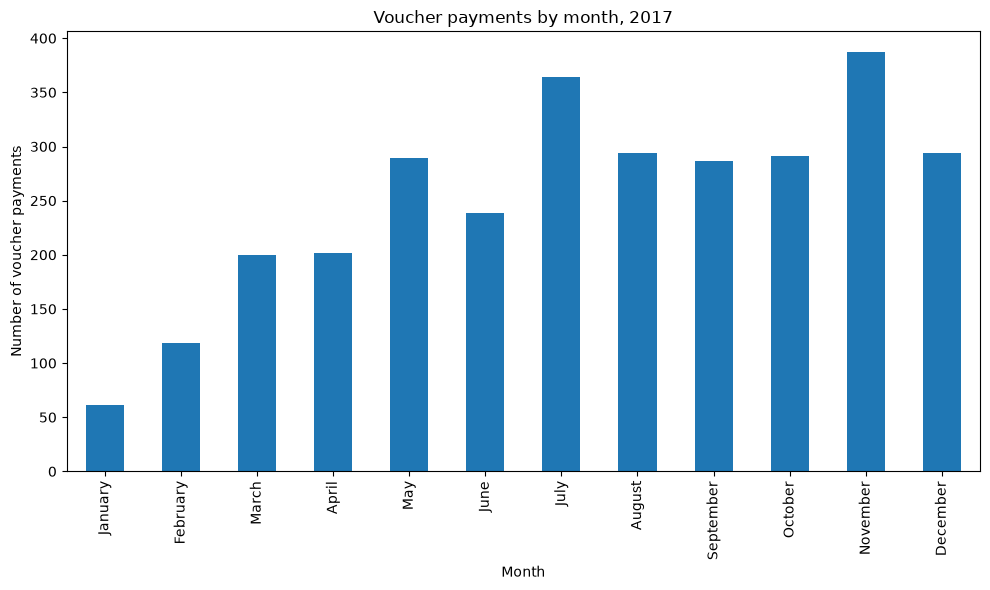

In [ ]:
monthly_2017_named = monthly_2017.copy()
monthly_2017_named.index = monthly_2017_named.index.map(lambda m: calendar.month_name[m])

monthly_2017_named.plot(kind='bar', figsize=(10, 6))
plt.title('Voucher payments by month, 2017')
plt.xlabel('Month')
plt.ylabel('Number of voucher payments')
plt.tight_layout()
plt.show()

> no peak in august,  The real peak is November, likely due to Black Friday sales

### Check for early vs late November to make sure if it's on Black Friday

In [44]:
window = aug[(aug['order_purchase_timestamp'] >= '2017-10-30') & (aug['order_purchase_timestamp'] < '2017-12-04')]
window = window.assign(is_voucher=window['payment_type'] == 'voucher')
weekly = (window.set_index('order_purchase_timestamp')['is_voucher'].resample('W').agg(['sum', 'count', 'mean']))


In [45]:
weekly['mean'] = weekly['mean'] * 100
weekly.columns = ['voucher_payments', 'all_payments', 'voucher_share_pct']
weekly

,voucher_payments,all_payments,voucher_share_pct
order_purchase_timestamp,,,
2017-11-05,46,974,4.722793
2017-11-12,77,1271,6.058222
2017-11-19,63,1361,4.628949
2017-11-26,142,3138,4.525175
2017-12-03,100,2184,4.578755


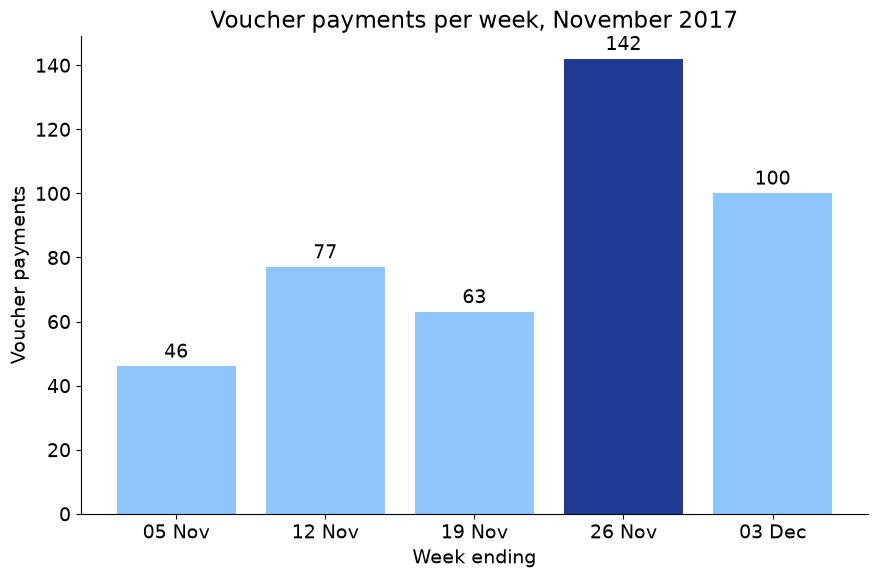

In [46]:
labels = weekly.index.strftime('%d %b')           
bf_week = pd.Timestamp('2017-11-26')            
colors = ['#1F3A93' if d == bf_week else '#8EC5FC' for d in weekly.index]

plt.rcParams['font.size'] = 14
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(labels, weekly['voucher_payments'], color=colors)
ax.bar_label(ax.containers[0], padding=3)

ax.set_title('Voucher payments per week, November 2017')
ax.set_xlabel('Week ending')
ax.set_ylabel('Voucher payments')
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

In [47]:
aug['order_purchase_timestamp']

0        2017-10-02 10:56:33
1        2017-10-02 10:56:33
2        2017-10-02 10:56:33
3        2018-07-24 20:41:37
4        2018-08-08 08:38:49
                 ...        
103882   2017-03-09 09:54:05
103883   2018-02-06 12:58:58
103884   2017-08-27 14:46:43
103885   2018-01-08 21:28:27
103886   2018-03-08 20:57:30
Name: order_purchase_timestamp, Length: 103887, dtype: datetime64[us]

In [48]:
# monthly_counts.plot(kind='bar', figsize=(10, 6))
# plt.title('Monthly Payment Counts for Voucher')
# plt.xlabel('Month')
# plt.ylabel('Number of payments')
# plt.tight_layout()
# plt.show()

> resulting chart for the above is misleading, so I commented it out

Boleto is NOT a voucher at all

## How does payment type (Credit Card, Boleto, Voucher, Debit) correlate with order value?

In [49]:
payment_types_per_order = olist_order_payments_df.groupby('order_id')['payment_type'].nunique()
single_type_orders = payment_types_per_order[payment_types_per_order == 1].index

In [50]:
clean_payments = olist_order_payments_df[olist_order_payments_df['order_id'].isin(single_type_orders)]
order_totals = clean_payments.groupby('order_id').agg({'payment_value': 'sum', 'payment_type': 'first'})

In [51]:
order_totals.groupby('payment_type')['payment_value'].describe()

,count,mean,std,min,25%,50%,75%,max
payment_type,,,,,,,,
boleto,19784.0,145.034435,213.581061,11.62,55.5225,93.89,160.7625,7274.88
credit_card,74259.0,166.946479,224.721094,10.07,64.2300,109.35,184.3500,13664.08
debit_card,1527.0,142.724158,245.917270,13.38,51.1100,89.30,154.3400,4445.50
not_defined,3.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
voucher,1621.0,114.387588,183.986218,11.56,45.2000,71.63,119.2500,3184.34


I pasted the output in a markdown below so that it looks better in VS code
> & I shared it w my group

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>count</th>
      <th>mean</th>
      <th>std</th>
      <th>min</th>
      <th>25%</th>
      <th>50%</th>
      <th>75%</th>
      <th>max</th>
    </tr>
    <tr>
      <th>payment_type</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>boleto</th>
      <td>19784.0</td>
      <td>145.034435</td>
      <td>213.581061</td>
      <td>11.62</td>
      <td>55.5225</td>
      <td>93.89</td>
      <td>160.7625</td>
      <td>7274.88</td>
    </tr>
    <tr>
      <th>credit_card</th>
      <td>74259.0</td>
      <td>166.946479</td>
      <td>224.721094</td>
      <td>10.07</td>
      <td>64.2300</td>
      <td>109.35</td>
      <td>184.3500</td>
      <td>13664.08</td>
    </tr>
    <tr>
      <th>debit_card</th>
      <td>1527.0</td>
      <td>142.724158</td>
      <td>245.917270</td>
      <td>13.38</td>
      <td>51.1100</td>
      <td>89.30</td>
      <td>154.3400</td>
      <td>4445.50</td>
    </tr>
    <tr>
      <th>not_defined</th>
      <td>3.0</td>
      <td>0.000000</td>
      <td>0.000000</td>
      <td>0.00</td>
      <td>0.0000</td>
      <td>0.00</td>
      <td>0.0000</td>
      <td>0.00</td>
    </tr>
    <tr>
      <th>voucher</th>
      <td>1621.0</td>
      <td>114.387588</td>
      <td>183.986218</td>
      <td>11.56</td>
      <td>45.2000</td>
      <td>71.63</td>
      <td>119.2500</td>
      <td>3184.34</td>
    </tr>
  </tbody>
</table>
</div>

Credit card is clearly the dominant payment method.
> AND it also has the highest order value.


> Vouchers have the lowest order value 

>not defined is filtered out in the next cell

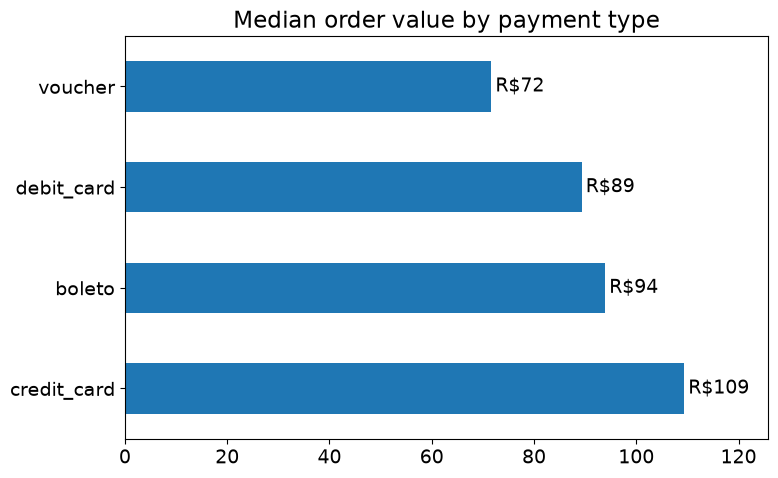

In [52]:
summary = (order_totals[order_totals['payment_type'] != 'not_defined'].groupby('payment_type')['payment_value']
           .agg(['median', 'mean', 'count'])
           .sort_values('median', ascending=False))

ax = summary['median'].plot(kind='barh', figsize=(8, 5))
ax.bar_label(ax.containers[0], fmt='R$%.0f', padding=3)
plt.title('Median order value by payment type')
plt.xlabel('')
plt.ylabel('')
plt.xlim(0, summary['median'].max() * 1.15)
plt.tight_layout()
plt.show()

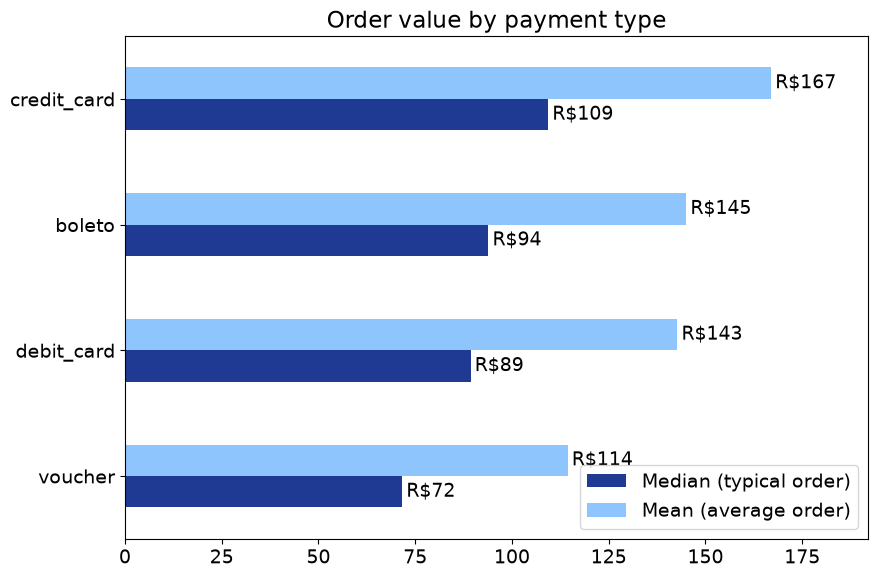

In [53]:
summary = summary.sort_values('median') 

ax = summary[['median', 'mean']].plot(kind='barh', figsize=(9, 6), color=['#1F3A93', '#8EC5FC'])
for c in ax.containers:
    ax.bar_label(c, fmt='R$%.0f', padding=3)

plt.xlim(0, summary['mean'].max() * 1.15)
plt.title('Order value by payment type')
plt.xlabel('')
plt.ylabel('')
plt.legend(['Median (typical order)', 'Mean (average order)'], loc='lower right')
plt.tight_layout()
plt.show()

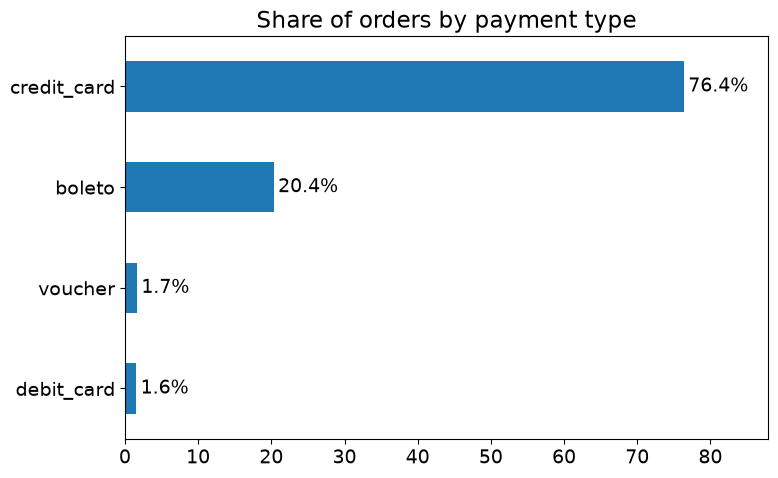

In [54]:
share = (summary['count'] / summary['count'].sum() * 100).sort_values()

ax = share.plot(kind='barh', figsize=(8, 5))
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

plt.xlim(0, share.max() * 1.15)
plt.title('Share of orders by payment type')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Are vouchers attracting new first-time buyers, or are they being used by existing customers who would have bought anyway?

In [55]:
print(olist_customers_df['customer_id'].nunique())

99441


In [56]:
print(olist_customers_df['customer_unique_id'].nunique())

96096


In [57]:
orders_cust = pd.merge(olist_orders_df, olist_customers_df[['customer_id', 'customer_unique_id']],on='customer_id', how='left')

In [58]:
orders_cust['purchase_ts'] = pd.to_datetime(orders_cust['order_purchase_timestamp'])
orders_cust = orders_cust.sort_values('purchase_ts')
orders_cust['order_number'] = orders_cust.groupby('customer_unique_id').cumcount() + 1
orders_cust['is_first_order'] = orders_cust['order_number'] == 1

In [59]:
orders_cust

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,purchase_ts,order_number,is_first_order
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,NaN,2016-10-20 00:00:00,b7d76e111c89f7ebf14761390f0f7d17,2016-09-04 21:15:19,1,True
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,NaN,NaN,2016-10-28 00:00:00,4854e9b3feff728c13ee5fc7d1547e92,2016-09-05 00:15:34,1,True
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,NaN,NaN,2016-09-30 00:00:00,009b0127b727ab0ba422f6d9604487c7,2016-09-13 15:24:19,1,True
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,830d5b7aaa3b6f1e9ad63703bec97d23,2016-09-15 12:16:38,1,True
83078,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02 22:07:52,2016-10-06 15:50:56,NaN,NaN,2016-10-25 00:00:00,0eb1ee9dba87f5b36b4613a65074337c,2016-10-02 22:07:52,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...
50387,392ed9afd714e3c74767d0c4d3e3f477,2823ffda607a2316375088e0d00005ec,canceled,2018-09-29 09:13:03,NaN,NaN,NaN,2018-10-15 00:00:00,9bb92bebd4cb7511e1a02d5e50bc4655,2018-09-29 09:13:03,1,True
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01 15:30:09,NaN,NaN,NaN,2018-10-23 00:00:00,634420a0ea42302205032ed44ac7fccc,2018-10-01 15:30:09,2,False
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03 18:55:29,NaN,NaN,NaN,2018-10-16 00:00:00,af5454198a97379394cacf676e1e96cb,2018-10-03 18:55:29,3,False
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16 20:16:02,NaN,NaN,NaN,2018-11-12 00:00:00,262e1f1e26e92e86375f86840b4ffd63,2018-10-16 20:16:02,2,False


In [ ]:
voucher_flag = (olist_order_payments_df.assign(used_voucher=olist_order_payments_df['payment_type'] == 'voucher').groupby('order_id')['used_voucher'].any().reset_index())

orders_cust = orders_cust.drop(columns='used_voucher', errors='ignore')
orders_cust = pd.merge(orders_cust, voucher_flag, on='order_id', how='left')
orders_cust['used_voucher'] = orders_cust['used_voucher'].fillna(False)

In [61]:
orders_cust.groupby('used_voucher')['is_first_order'].mean() * 100

used_voucher
False    96.752289
True     93.766167
Name: is_first_order, dtype: float64

>to be filled 

In [62]:
orders_per_customer = (orders_cust.groupby('customer_unique_id')['order_id']
                       .count().rename('n_orders').reset_index())

first_orders = orders_cust[orders_cust['is_first_order']]
first_orders = pd.merge(first_orders, orders_per_customer, on='customer_unique_id')
first_orders['came_back'] = first_orders['n_orders'] > 1

first_orders.groupby('used_voucher')['came_back'].mean() * 100

used_voucher
False    3.088536
True     3.889655
Name: came_back, dtype: float64

In [63]:
first_orders.groupby('used_voucher')['came_back'].agg(['sum', 'count'])

,sum,count
used_voucher,,
False,2856,92471
True,141,3625


In [64]:
first_2017 = first_orders[first_orders['purchase_ts'].dt.year == 2017]
first_2017.groupby('used_voucher')['came_back'].mean() * 100

used_voucher
False    4.246579
True     5.111474
Name: came_back, dtype: float64

In [65]:
(orders_per_customer['n_orders'] > 1).mean()*100

np.float64(3.1187562437562435)

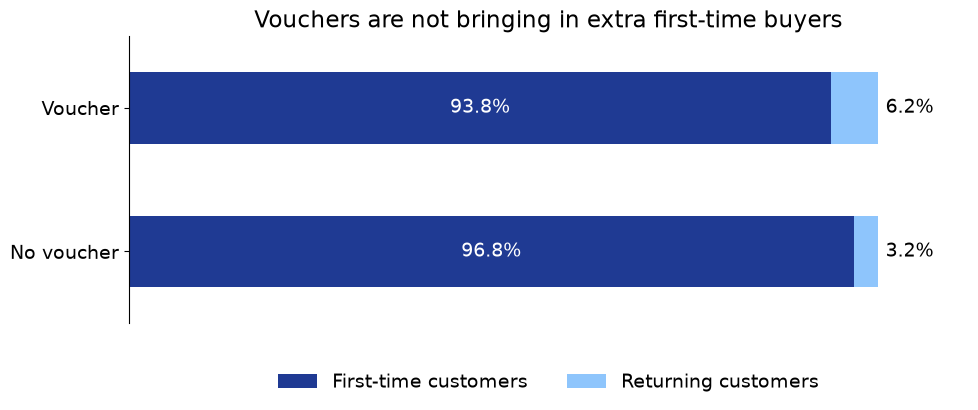

In [66]:
first_share = orders_cust.groupby('used_voucher')['is_first_order'].mean() * 100
first_share.index = ['No voucher', 'Voucher']

plot_df = pd.DataFrame({'First-time customers': first_share,'Returning customers': 100 - first_share})

plt.rcParams['font.size'] = 14
ax = plot_df.plot(kind='barh', stacked=True, figsize=(10, 4.5),
                  color=['#1F3A93', '#8EC5FC'])

ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='center', color='white')
for bar, val in zip(ax.containers[1], plot_df['Returning customers']):
    ax.text(101, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center')

plt.xlim(0, 112)
plt.title('Vouchers are not bringing in extra first-time buyers')
plt.xlabel('')
plt.ylabel('')
ax.set_xticks([])
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
for s in ('top', 'right', 'bottom'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

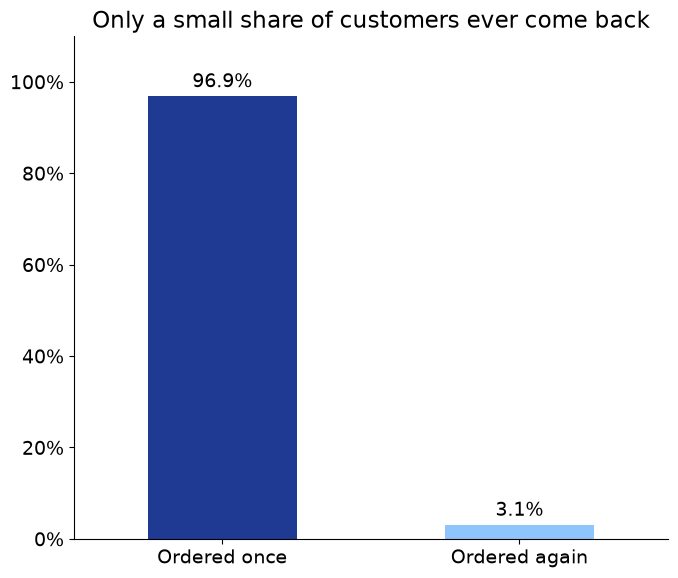

In [67]:


returned = (orders_per_customer['n_orders'] > 1).mean() * 100
share = pd.Series({'Ordered once': 100 - returned, 'Ordered again': returned})

plt.rcParams['font.size'] = 14
ax = share.plot(kind='bar', figsize=(7, 6), color=['#1F3A93', '#8EC5FC'], rot=0)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)

plt.ylim(0, 110)
ax.yaxis.set_major_formatter(PercentFormatter())
plt.title('Only a small share of customers ever come back')

for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

*Reset the chart font size so charts in the next part start from the default settings.*

In [68]:
plt.rcParams['font.size'] = plt.rcParamsDefault['font.size']

# Part 3 - Products, shipping, installments and cancellations (Isa)

In [69]:
data_dir = pathlib.Path("../Data/")

## Merge Dataframes

In [70]:
merge_method = "inner"

In [71]:
def ignore(x):
    return x

In [72]:
order_items_df = pd.read_csv(data_dir.joinpath("olist_order_items_dataset.csv"))
payments_df = pd.read_csv(data_dir.joinpath("olist_order_payments_dataset.csv"))

In [73]:
products_df = pd.read_csv(data_dir.joinpath("olist_products_dataset.csv"))

In [74]:
product_id_to_name = (
    products_df[["product_id", "product_category_name"]]
    .set_index("product_id")
    .to_dict()["product_category_name"]
)

In [75]:
order_items_df["product_id"] = order_items_df["product_id"].map(product_id_to_name)
order_items_df.rename(columns={"product_id": "product_category"}, inplace=True)

Determine Whether Product is Expensive or Not

$\rightarrow$ product is considered expensive if its price $P \gt \bar{P}$ where $\bar{P}$ is the mean of all product prices, otherwise it's considered cheaper

In [76]:
products = order_items_df.groupby(["product_category"])["price"].mean()
mean_product_price = products.values.mean()
order_items_df["price_category"] = order_items_df["product_category"].apply(
    lambda x: "More Expensive"
    if products.get(x, np.nan) > mean_product_price
    else "Cheaper"
)

In [77]:
aggregation_dict = {
    "order_item_id": tuple,
    "product_category": tuple,
    "seller_id": tuple,
    "shipping_limit_date": tuple,
    "price": tuple,
    "freight_value": tuple,
    "price_category": tuple,
}

order_items_df = (
    order_items_df.groupby(["order_id"]).aggregate(aggregation_dict).reset_index()
)

In [78]:
order_items_df["total_price"] = order_items_df["price"].apply(sum)
order_items_df["total_freight"] = order_items_df["freight_value"].apply(sum)
order_items_df["full_price"] = (
    order_items_df["total_price"] + order_items_df["total_freight"]
)

In [79]:
aggregation_dict = {
    "payment_sequential": max,
    "payment_type": tuple,
    "payment_installments": sum,
    "payment_value": sum,
}
payments_df = payments_df.groupby("order_id").aggregate(aggregation_dict).reset_index()

In [80]:
order_items_payments_df = pd.merge(
    order_items_df, payments_df, on="order_id", how=merge_method
)

In [81]:
orders_df = pd.read_csv(data_dir.joinpath("olist_orders_dataset.csv"))
orders_payments_df = pd.merge(
    order_items_payments_df, orders_df, on="order_id", how=merge_method
)

In [82]:
customer_info_df = pd.read_csv(data_dir.joinpath("olist_customers_dataset.csv"))

customer_orders_df = pd.merge(
    orders_payments_df, customer_info_df, on="customer_id", how=merge_method
)

In [83]:
order_review_df = pd.read_csv(data_dir.joinpath("olist_order_reviews_dataset.csv"))

In [84]:
order_review_df = order_review_df.groupby(["order_id"]).aggregate(tuple).reset_index()

In [85]:
df = pd.merge(customer_orders_df, order_review_df, on="order_id", how=merge_method)

Free Memory

In [86]:
# free memory; pop() so this cell can be run again without a NameError
for _name in ['order_review_df', 'customer_orders_df', 'customer_info_df', 'orders_payments_df', 'orders_df', 'order_items_df', 'order_items_payments_df', 'products_df']:
    globals().pop(_name, None)

## Charts

### Installment Use by Product Category (Frequency)

In [87]:
df["used_installments"] = df["payment_installments"].explode().apply(lambda x: x > 1)

Text(0.5, 1.0, 'Installment Use by Product Category')

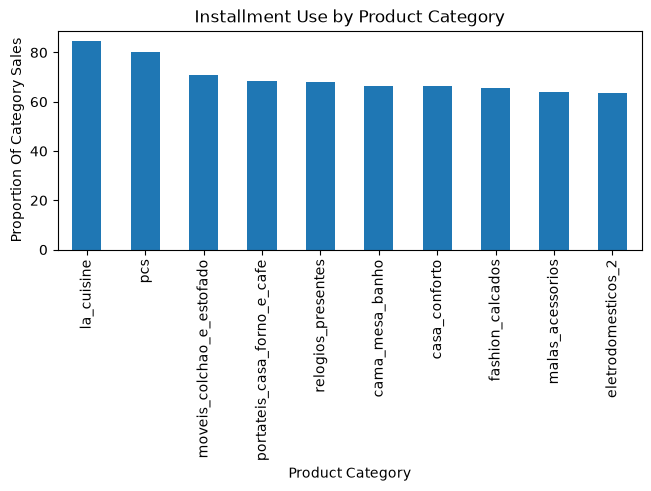

In [88]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    (
        (
            df.explode("payment_installments")
            .explode("product_category")
            .groupby(["used_installments"])["product_category"]
            .value_counts(ascending=False)
            / df.explode("payment_installments")
            .explode("product_category")["product_category"]
            .value_counts()
        )
        * 100
    )[True]
    .nlargest(10)
    .plot(kind="bar")
)

ax.set_ylabel("Proportion Of Category Sales")
ax.set_xlabel("Product Category")
ax.set_title("Installment Use by Product Category")

### Installment Use by Customer State

Text(0.5, 1.0, 'Installment Use by Customer State')

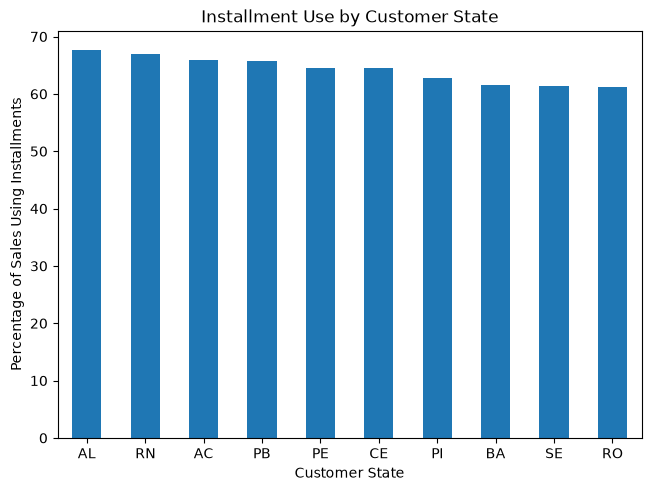

In [89]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    (
        df.explode("payment_installments")
        .explode("product_category")
        .drop_duplicates()
        .groupby(["used_installments"])["customer_state"]
        .value_counts(ascending=False)
        / df.explode("payment_installments")
        .explode("product_category")
        .drop_duplicates()
        .groupby("customer_state")["customer_id"]
        .count()
        * 100
    )[True]
    .nlargest(10)
    .plot(kind="bar", rot=0)
)

ax.set_ylabel("Percentage of Sales Using Installments")
ax.set_xlabel("Customer State")
ax.set_title("Installment Use by Customer State")

### Installments by Product Category (Average Installment Count)

Text(0.5, 1.0, 'Average Number of Installments by Product Category')

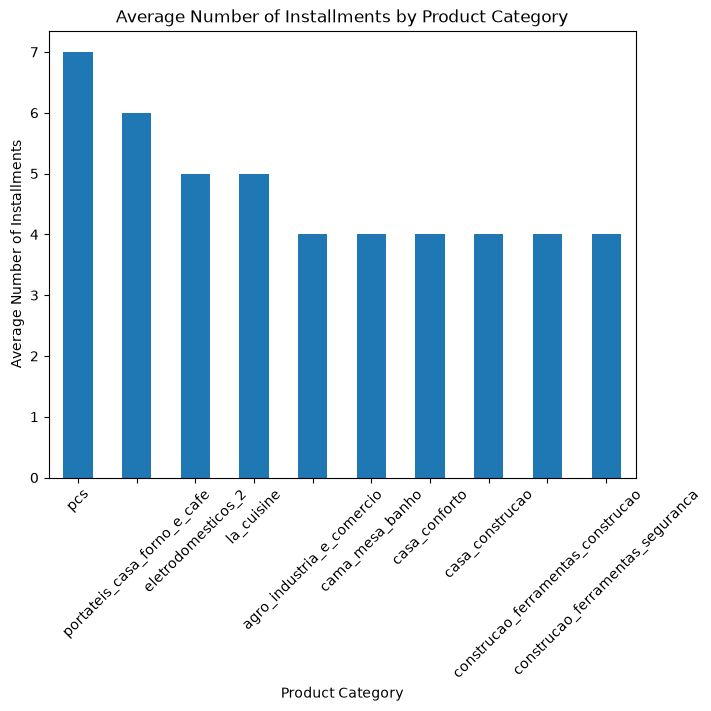

In [90]:
fig, ax = plt.subplots(figsize=(7, 7), layout="constrained")
ax = (
    round(
        (
            df.explode("payment_installments")
            .explode("product_category")
            .groupby(["product_category"])["payment_installments"]
            .mean()
        )
    )
    .nlargest(10)
    .plot(kind="bar", rot=45)
)
ax.set_ylabel("Average Number of Installments")
ax.set_xlabel("Product Category")
ax.set_title("Average Number of Installments by Product Category")

### Sale Amount by Installment Usage

[Text(0, 0, 'Single Installment'), Text(1, 0, 'Multiple Installments')]

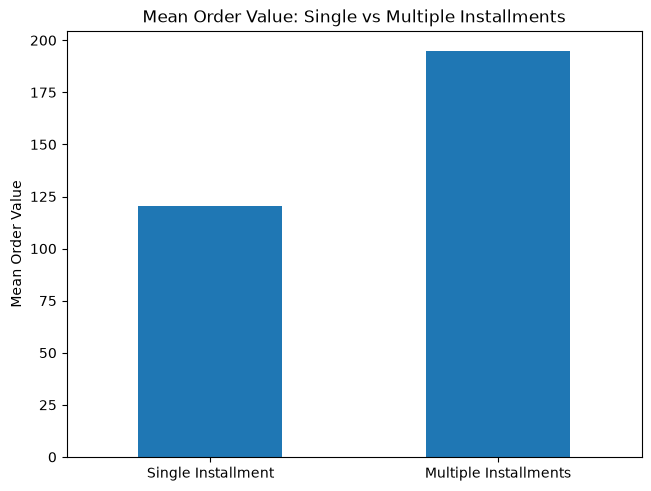

In [91]:
fig, ax = plt.subplots(layout="constrained")
ax = df.groupby(["used_installments"])["full_price"].mean().plot(kind="bar", rot=0)
ax.set_ylabel("Mean Order Value")
ax.set_xlabel("")
ax.set_title("Mean Order Value: Single vs Multiple Installments")
ax.set_xticklabels(["Single Installment", "Multiple Installments"])

### Cheap vs Expensive 

In [92]:
products = (
    df.explode("product_category").groupby(["product_category"])["full_price"].mean()
)

In [93]:
product_categories = (
    df.explode("product_category").explode("price_category").drop_duplicates()
)
product_categories.shape

(99047, 33)

Text(0.5, 1.0, 'Percentage of Products in Each Price Category')

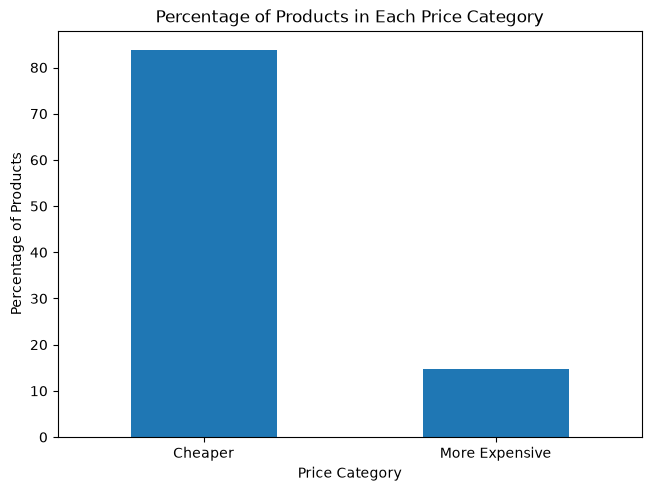

In [94]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    (
        product_categories.explode("price_category")
        .explode("product_category")
        .drop_duplicates()
        .groupby("price_category")["product_category"]
        .count()
        / product_categories.shape[0]
    )
    * 100
).plot(kind="bar", rot=0)


ax.set_xlabel("Price Category")
ax.set_ylabel("Percentage of Products")
ax.set_title("Percentage of Products in Each Price Category")

### Cancelled Orders

In [95]:
cancel_other = (
    df[df["used_installments"] == False]["order_status"].value_counts(normalize=True)
    * 100
)["canceled"]

In [96]:
cancel_installations = (
    df[df["used_installments"] == True]["order_status"].value_counts(normalize=True)
    * 100
)["canceled"]

Text(0.5, 1.0, 'Percentage of Cancelled Orders Based on Payment Plan')

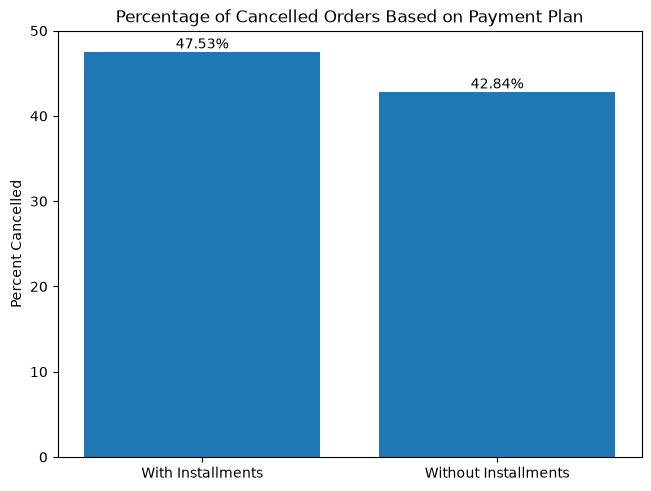

In [97]:
fig, ax = plt.subplots(layout="constrained")

bars = ax.bar(
    ["With Installments", "Without Installments"], [cancel_installations, cancel_other]
)

ax.bar_label(bars, fmt="{:.2%}")
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_yticklabels(range(0, 101, 10))
ax.set_ylim(top=0.5)

ax.set_ylabel("Percent Cancelled")
ax.set_title("Percentage of Cancelled Orders Based on Payment Plan")

### Freight Value Reasonable?

Freight is 20.88% of the (product + freight) price


In [98]:
(df["total_freight"] / df["full_price"]).mean() * 100

np.float64(20.883638404245033)

Freight is 30.84% of Product Price

In [99]:
(df["total_freight"] / df["total_price"]).mean() * 100

np.float64(30.843374261254304)

### Mean Price With Payment Method

Text(0.5, 1.0, 'How Mean Sale Price Changes With Payment Method')

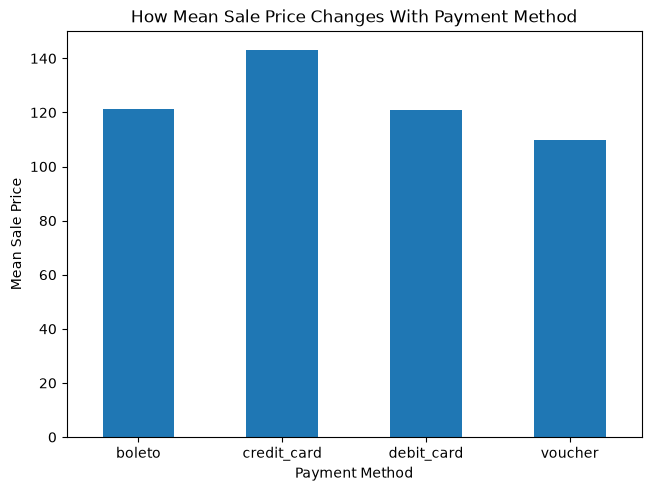

In [100]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    df.explode("full_price")
    .explode("payment_type")
    .drop_duplicates()
    .groupby("payment_type")["total_price"]
    .aggregate("mean")
    .plot(kind="bar", rot=0)
)
ax.set_ylabel("Mean Sale Price")
ax.set_xlabel("Payment Method")
ax.set_title("How Mean Sale Price Changes With Payment Method")

### Installments Across Price Ranges

In [101]:
df[df["full_price"] > 2000].count().iloc[0]

# There are only 206 orders where the full price is > 2000

np.int64(206)

In [102]:
bins = list(range(0, 2001, 100))
labels = [f"{val-100}-{val}" for val in bins[1:]]
labels.append(">2000")
bins.append(np.inf)

df["payment_range"] = pd.cut(
    df["full_price"], bins=bins, labels=labels, include_lowest=True
)

Text(0.5, 1.0, 'Average Number of Installments Across Different Price Ranges')

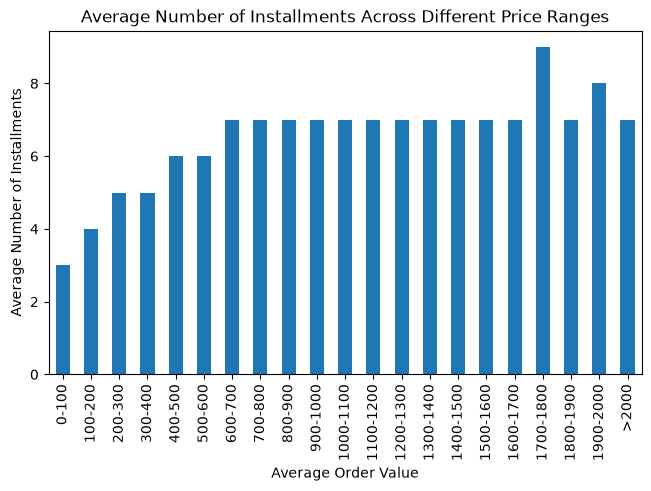

In [103]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    df.explode("payment_installments")
    .drop_duplicates()
    .groupby(["payment_range"])["payment_installments"]
    .aggregate(lambda x: np.ceil(x.mean()))
    .sort_index()
    .plot(kind="bar")
)
ax.set_xlabel("Average Order Value")
ax.set_ylabel("Average Number of Installments")
ax.set_title("Average Number of Installments Across Different Price Ranges")

### Distribution of Installment Counts

Text(0.5, 1.0, 'Installment Count Frequency Across Total Purchases')

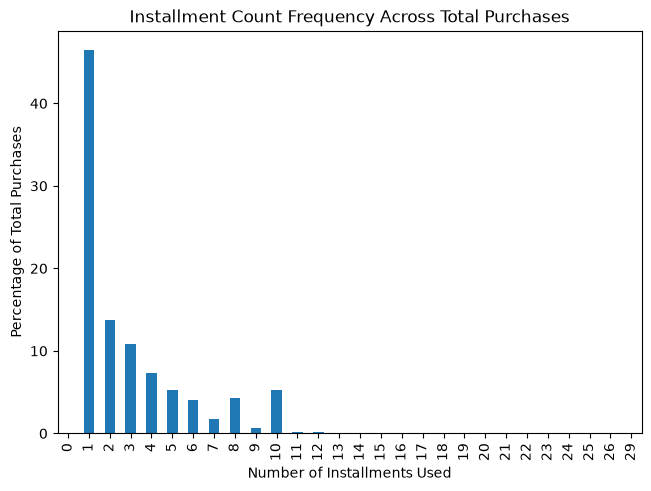

In [104]:
fig, ax = plt.subplots(layout="constrained")
ax = (df["payment_installments"].value_counts(normalize=True).sort_index() * 100).plot(
    kind="bar"
)
ax.set_ylabel("Percentage of Total Purchases")
ax.set_xlabel("Number of Installments Used")
ax.set_title("Installment Count Frequency Across Total Purchases")

### Voucher State Distribution

Text(0.5, 1.0, 'Distribution of Vouchers Among States')

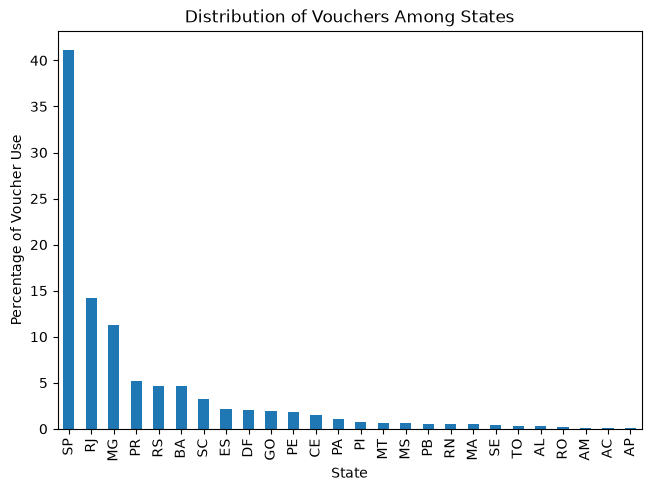

In [105]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    df.explode("payment_type")[df["payment_type"].explode() == "voucher"]
    .drop_duplicates()["customer_state"]
    .value_counts(normalize=True)
    * 100
).plot(kind="bar")
ax.set_ylabel("Percentage of Voucher Use")
ax.set_xlabel("State")
ax.set_title("Distribution of Vouchers Among States")

### Cancelled Orders By Region

Text(0.5, 1.0, "Distribution of Cancelled Orders as a Proportion of Each State's Total Orders")

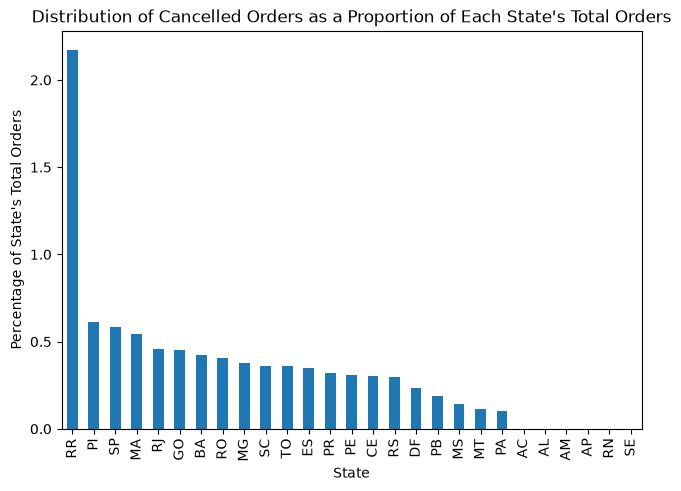

In [106]:
fig, ax = plt.subplots(layout="constrained")
ax = (
    (
        (
            df[df["order_status"] == "canceled"]["customer_state"].value_counts()
            / df["customer_state"].value_counts()
        )
        * 100
    )
    .sort_values(ascending=False)
    .plot(kind="bar")
)
ax.set_ylabel("Percentage of State's Total Orders")
ax.set_xlabel("State")
ax.set_title(
    "Distribution of Cancelled Orders as a Proportion of Each State's Total Orders"
)